### EDA Pipeline

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split


def ml_lab_pipeline(file_path,
                    target_column=None,
                    k=10,
                    random_state=42):
    

    # ==========================
    # LOAD DATASET
    # ==========================
    if file_path.endswith(".csv"):
        df = pd.read_csv(file_path)

    elif file_path.endswith(".xlsx"):
        df = pd.read_excel(file_path)

    elif file_path.endswith(".data"):
        df = pd.read_csv(file_path)

    else:
        raise ValueError("Only CSV, XLSX and DATA files are supported.")

    print("="*60)
    print("DATASET LOADED")
    print("="*60)

    print(df.head())
    print(df.info())
    print(df.describe(include="all"))

    # ==========================
    # MISSING VALUES
    # ==========================
    print("\nMissing Values")
    print(df.isnull().sum())

    if df.isnull().sum().sum() > 0:
        plt.figure(figsize=(8,4))
        df.isnull().sum()[df.isnull().sum()>0].sort_values().plot(kind="barh")
        plt.title("Missing Values")
        plt.show()

    # ==========================
    # DUPLICATES
    # ==========================
    duplicates = df.duplicated().sum()
    print("\nDuplicate Rows:", duplicates)

    # ==========================
    # UNIQUE VALUES
    # ==========================
    print("\nUnique Values")

    for col in df.columns:
        print(col, ":", df[col].nunique())

    # ==========================
    # COLUMN TYPES
    # ==========================
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

    print("\nNumerical Columns")
    print(num_cols)

    print("\nCategorical Columns")
    print(cat_cols)

    # ==========================
    # COUNT PLOTS
    # ==========================
    for col in cat_cols:

        print(f"\nValue Counts of {col}")
        print(df[col].value_counts())

        plt.figure(figsize=(7,4))
        sns.countplot(data=df, x=col)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    # ==========================
    # HISTOGRAM & BOXPLOT
    # ==========================
    for col in num_cols:

        fig, ax = plt.subplots(1,2, figsize=(12,4))

        sns.histplot(df[col], kde=True, ax=ax[0])
        ax[0].set_title(col)

        sns.boxplot(x=df[col], ax=ax[1])

        plt.tight_layout()
        plt.show()

    # ==========================
    # CORRELATION
    # ==========================
    if len(num_cols) > 1:

        plt.figure(figsize=(10,8))

        sns.heatmap(df[num_cols].corr(),
                    annot=True,
                    cmap="coolwarm",
                    fmt=".2f")

        plt.title("Correlation Matrix")
        plt.show()

    # ==========================
    # PAIRPLOT
    # ==========================
    if len(num_cols) <= 6:

        sns.pairplot(df[num_cols])
        plt.show()

    else:

        print("Pairplot skipped.")

    # ==========================
    # OUTLIERS
    # ==========================
    print("\nOutlier Count")

    for col in num_cols:

        Q1 = df[col].quantile(.25)
        Q3 = df[col].quantile(.75)

        IQR = Q3-Q1

        lower = Q1-1.5*IQR
        upper = Q3+1.5*IQR

        outliers=((df[col]<lower)|(df[col]>upper)).sum()

        print(col,":",outliers)

    # ==========================
    # SUPERVISED / UNSUPERVISED
    # ==========================
    if target_column is None:

        print("\nDataset Type : UNSUPERVISED")
        print("\nEDA Completed Successfully")

        return df

    if target_column not in df.columns:

        raise ValueError("Target column not found.")

    X=df.drop(target_column,axis=1)
    y=df[target_column]

    if y.dtype=="object" or y.nunique()<=20:
        print("\nLearning Type : SUPERVISED")
        print("Problem : Classification")
    else:
        print("\nLearning Type : SUPERVISED")
        print("Problem : Regression")

    # ==========================
    # CLASS DISTRIBUTION
    # ==========================
    if y.dtype=="object" or y.nunique()<=20:

        plt.figure(figsize=(6,4))
        y.value_counts().plot(kind="bar")
        plt.title("Class Distribution")
        plt.show()

    # ==========================
    # SKEWNESS & KURTOSIS
    # ==========================
    print("\nSkewness")

    for col in num_cols:
        print(col,":",round(df[col].skew(),3))

    print("\nKurtosis")

    for col in num_cols:
        print(col,":",round(df[col].kurtosis(),3))

    # ==========================
    # LABEL ENCODING
    # ==========================
    le=LabelEncoder()

    for col in X.select_dtypes(include="object").columns:
        X[col]=le.fit_transform(X[col].astype(str))

    if y.dtype=="object":
        y=le.fit_transform(y)

    # ==========================
    # FEATURE SELECTION
    # ==========================
    k=min(k,X.shape[1])

    selector=SelectKBest(score_func=f_classif,k=k)

    selector.fit(X,y)

    selected_features=X.columns[selector.get_support()]

    print("\nSelected Features")
    print(selected_features.tolist())

    scores=pd.DataFrame({
        "Feature":X.columns,
        "Score":selector.scores_
    })

    scores=scores.sort_values("Score",ascending=False)

    print("\nFeature Scores")
    print(scores)

    # ==========================
    # TRAIN / VALIDATION / TEST
    # ==========================
    X_train,X_temp,y_train,y_temp=train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=random_state
    )

    X_val,X_test,y_val,y_test=train_test_split(
        X_temp,
        y_temp,
        test_size=0.50,
        random_state=random_state
    )

    print("\nDataset Split")
    print("Training :",X_train.shape)
    print("Validation :",X_val.shape)
    print("Testing :",X_test.shape)

    print("\nEDA Completed Successfully")

    return {
        "df":df,
        "X_train":X_train,
        "X_val":X_val,
        "X_test":X_test,
        "y_train":y_train,
        "y_val":y_val,
        "y_test":y_test,
        "selected_features":selected_features,
        "feature_scores":scores
    }

DATASET LOADED
  Customer ID              Name Gender  Age  Income (USD) Income Stability  \
0     C-26247  Tandra Olszewski      F   47       3472.69              Low   
1     C-35067     Jeannette Cha      F   57       1184.84              Low   
2     C-34590      Keva Godfrey      F   52       1266.27              Low   
3     C-16668      Elva Sackett      M   65       1369.72             High   
4     C-12196    Sade Constable      F   60       1939.23             High   

             Profession Type of Employment    Location  \
0  Commercial associate           Managers  Semi-Urban   
1               Working        Sales staff       Rural   
2               Working                NaN  Semi-Urban   
3             Pensioner                NaN       Rural   
4             Pensioner                NaN       Urban   

   Loan Amount Request (USD)  ...  Dependents Credit Score No. of Defaults  \
0                  137088.98  ...         2.0       799.14               0   
1          

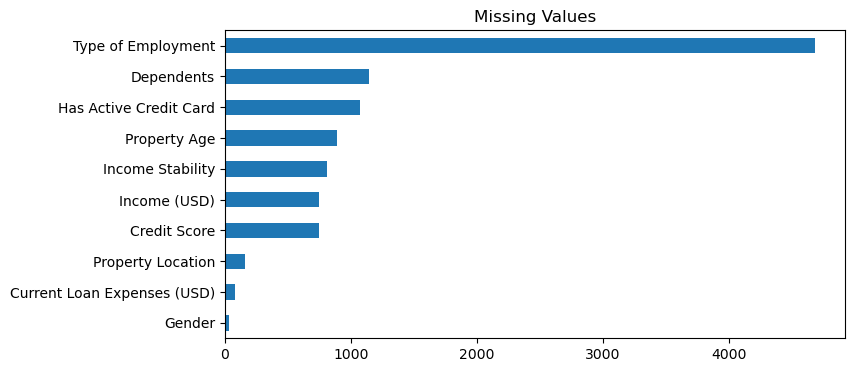


Duplicate Rows: 0

Unique Values
Customer ID : 20000
Name : 20000
Gender : 2
Age : 48
Income (USD) : 18693
Income Stability : 2
Profession : 7
Type of Employment : 18
Location : 3
Loan Amount Request (USD) : 19988
Current Loan Expenses (USD) : 17247
Expense Type 1 : 2
Expense Type 2 : 2
Dependents : 10
Credit Score : 13756
No. of Defaults : 2
Has Active Credit Card : 3
Property ID : 999
Property Age : 18560
Property Type : 4
Property Location : 3
Co-Applicant : 3
Property Price : 19824

Numerical Columns
['Age', 'Income (USD)', 'Loan Amount Request (USD)', 'Current Loan Expenses (USD)', 'Dependents', 'Credit Score', 'No. of Defaults', 'Property ID', 'Property Age', 'Property Type']

Categorical Columns
['Customer ID', 'Name', 'Gender', 'Income Stability', 'Profession', 'Type of Employment', 'Location', 'Expense Type 1', 'Expense Type 2', 'Has Active Credit Card', 'Property Location', 'Co-Applicant', 'Property Price']

Value Counts of Customer ID
Customer ID
C-26247    1
C-40981    1
C

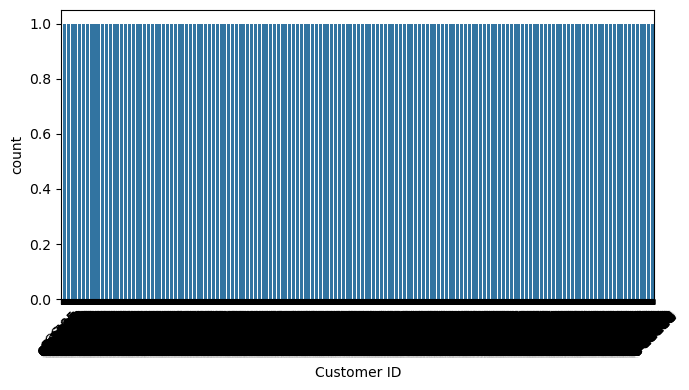


Value Counts of Name
Name
Tandra Olszewski       1
Meghan Afanador        1
Nilda Ames             1
Nicki Arviso           1
Christiana Domenech    1
                      ..
Nolan Bumbalough       1
Marquerite Snelling    1
Sol Coggin             1
Kathey Corkill         1
Mechelle Boddie        1
Name: count, Length: 20000, dtype: int64


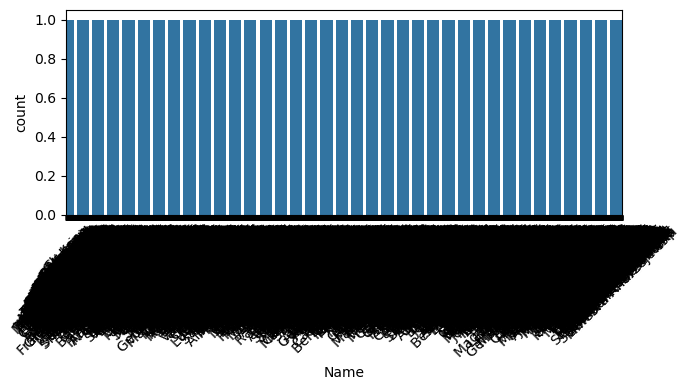


Value Counts of Gender
Gender
F    10142
M     9827
Name: count, dtype: int64


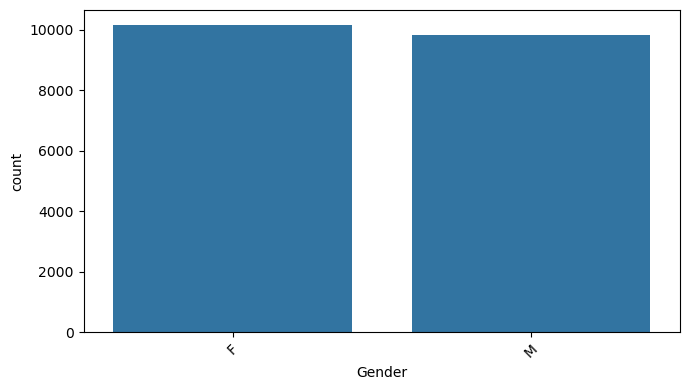


Value Counts of Income Stability
Income Stability
Low     17501
High     1686
Name: count, dtype: int64


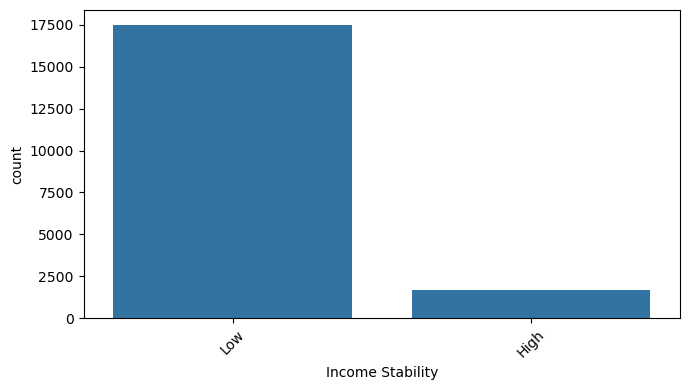


Value Counts of Profession
Profession
Working                 11405
Commercial associate     5247
Pensioner                1764
State servant            1577
Student                     4
Unemployed                  2
Maternity leave             1
Name: count, dtype: int64


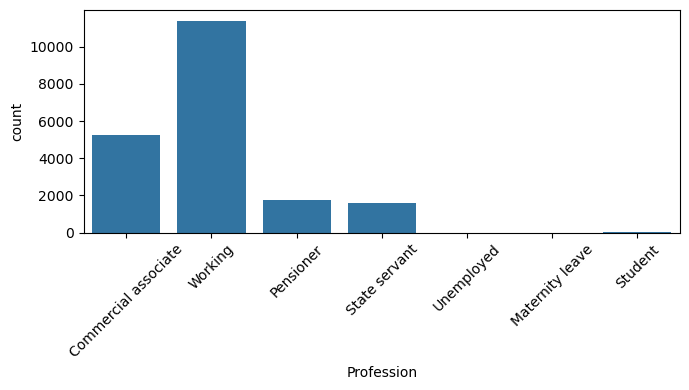


Value Counts of Type of Employment
Type of Employment
Laborers                 3743
Sales staff              2433
Core staff               2232
Managers                 1719
Drivers                  1057
Accountants               886
High skill tech staff     881
Medicine staff            598
Cooking staff             405
Security staff            377
Cleaning staff            230
Private service staff     201
Low-skill Laborers        141
Secretaries               119
Waiters/barmen staff      110
Realty agents              68
HR staff                   60
IT staff                   51
Name: count, dtype: int64


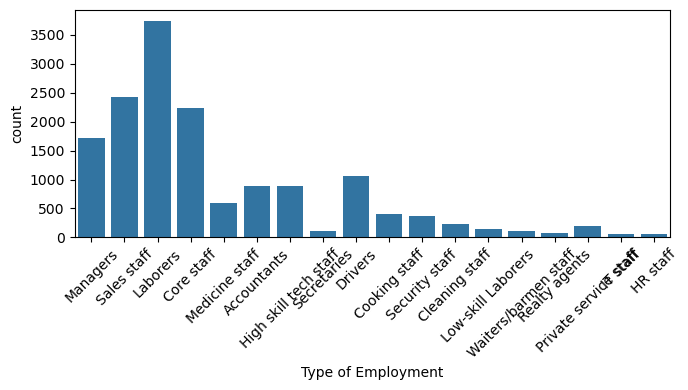


Value Counts of Location
Location
Semi-Urban    14463
Rural          3436
Urban          2101
Name: count, dtype: int64


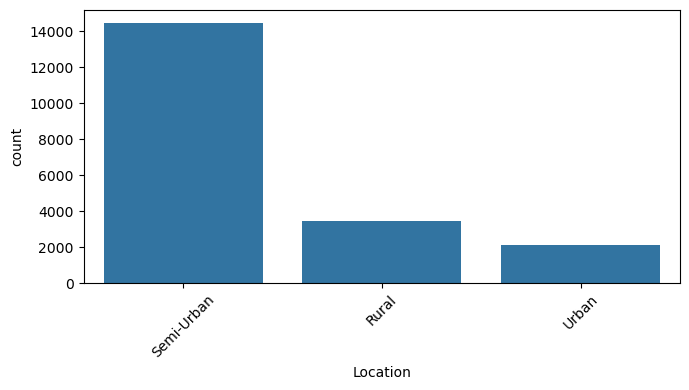


Value Counts of Expense Type 1
Expense Type 1
N    12816
Y     7184
Name: count, dtype: int64


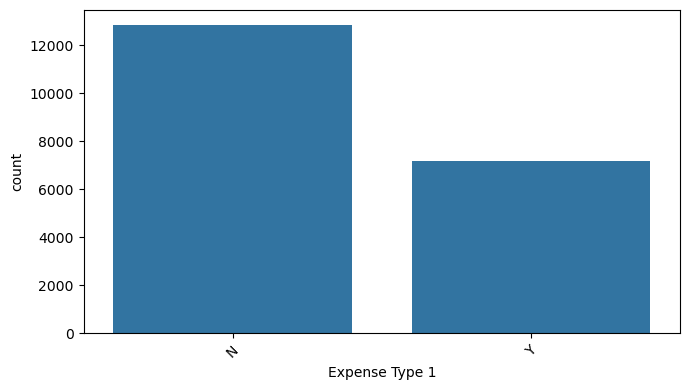


Value Counts of Expense Type 2
Expense Type 2
Y    13383
N     6617
Name: count, dtype: int64


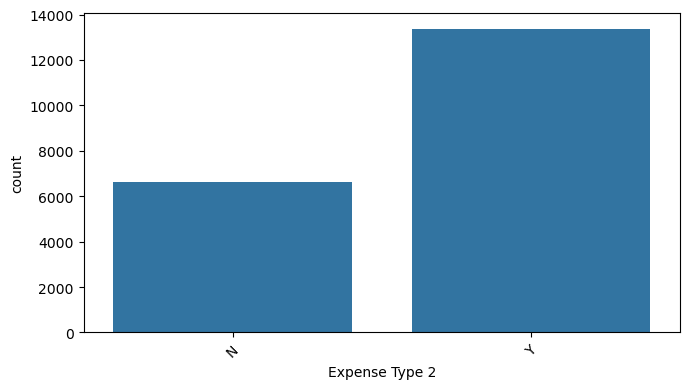


Value Counts of Has Active Credit Card
Has Active Credit Card
Active         6418
Inactive       6376
Unpossessed    6130
Name: count, dtype: int64


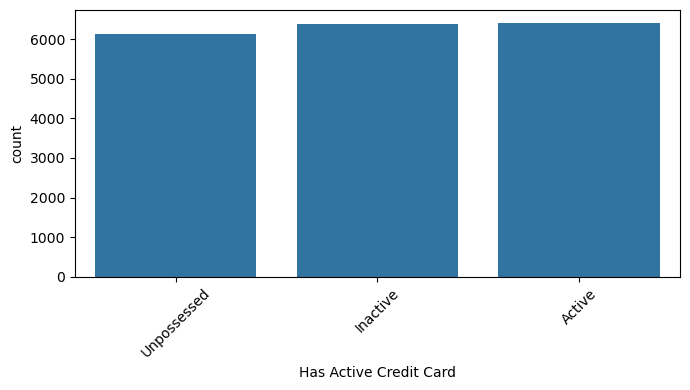


Value Counts of Property Location
Property Location
Semi-Urban    6839
Rural         6768
Urban         6233
Name: count, dtype: int64


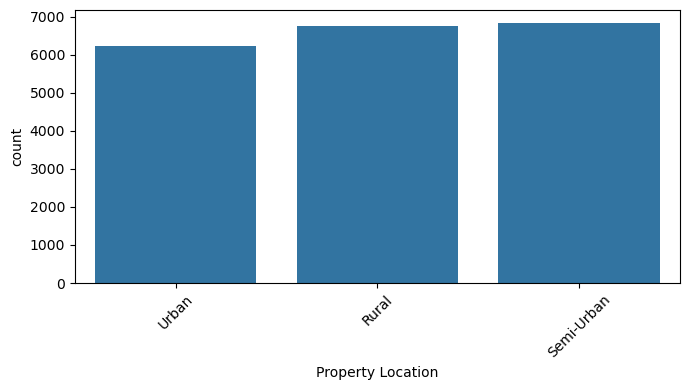


Value Counts of Co-Applicant
Co-Applicant
1    17004
0     2919
?       77
Name: count, dtype: int64


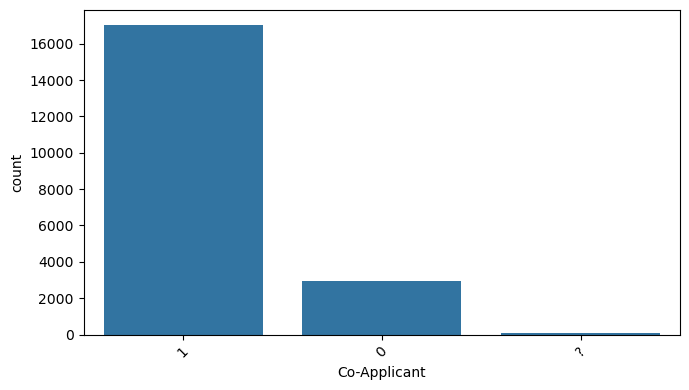


Value Counts of Property Price
Property Price
?            168
60060.83       2
75656.14       2
77441.22       2
88372.15       2
            ... 
49549.13       1
106299.73      1
300422.52      1
128915.76      1
133425.43      1
Name: count, Length: 19824, dtype: int64


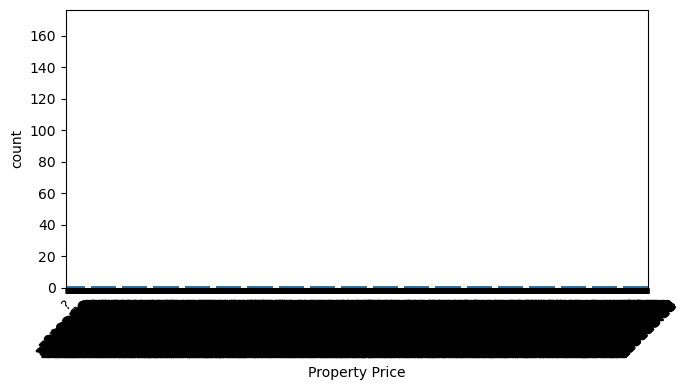

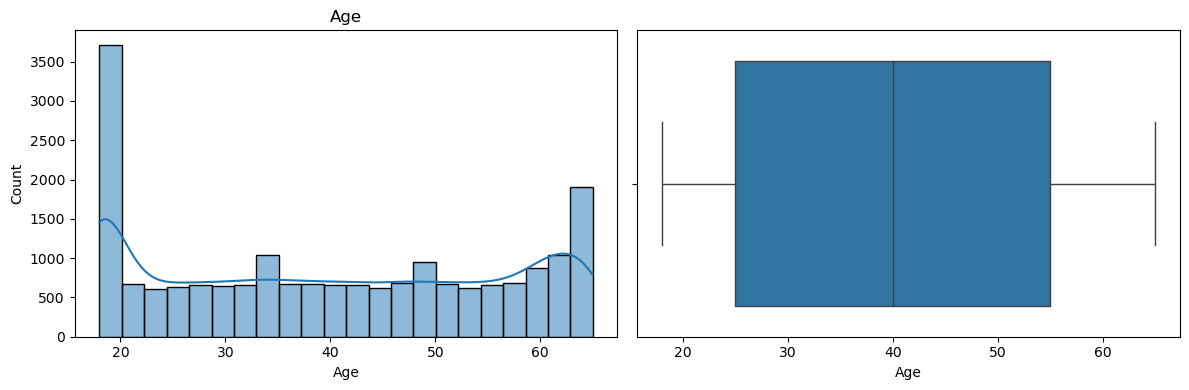

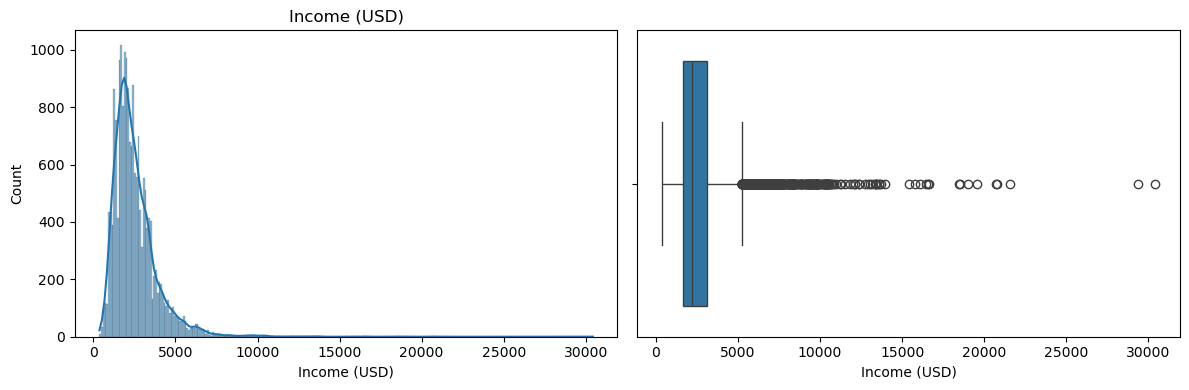

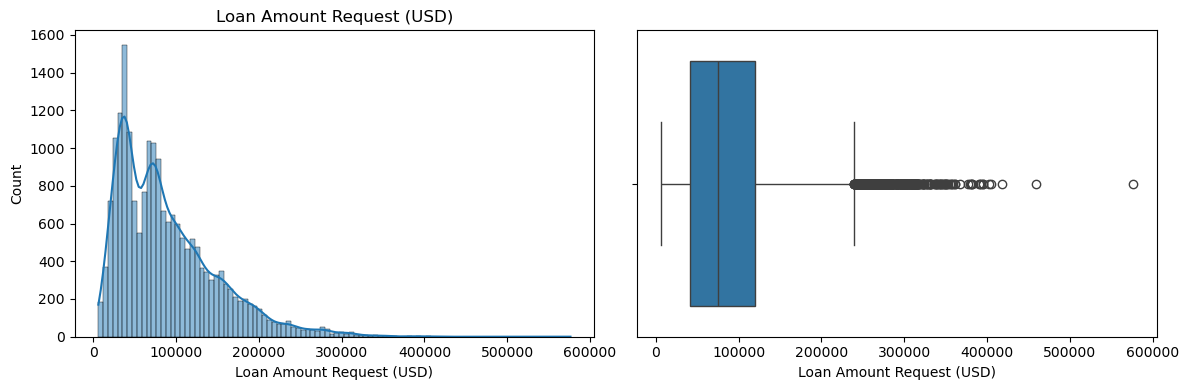

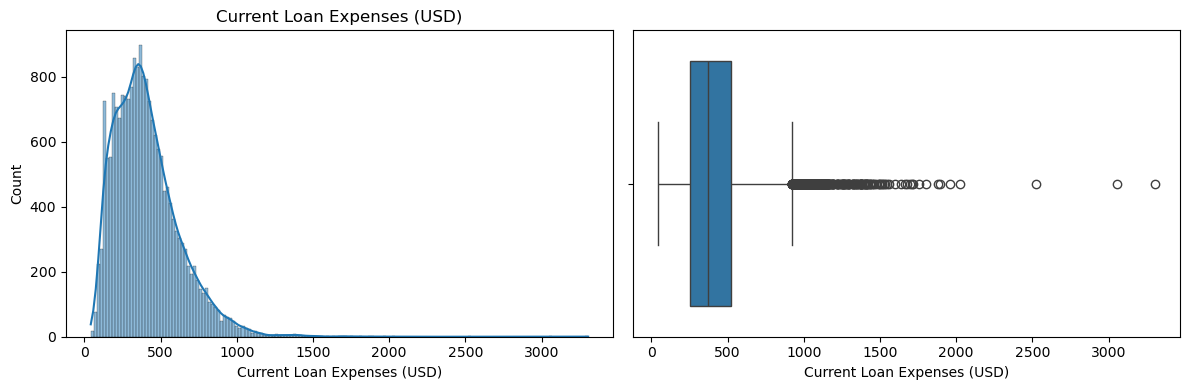

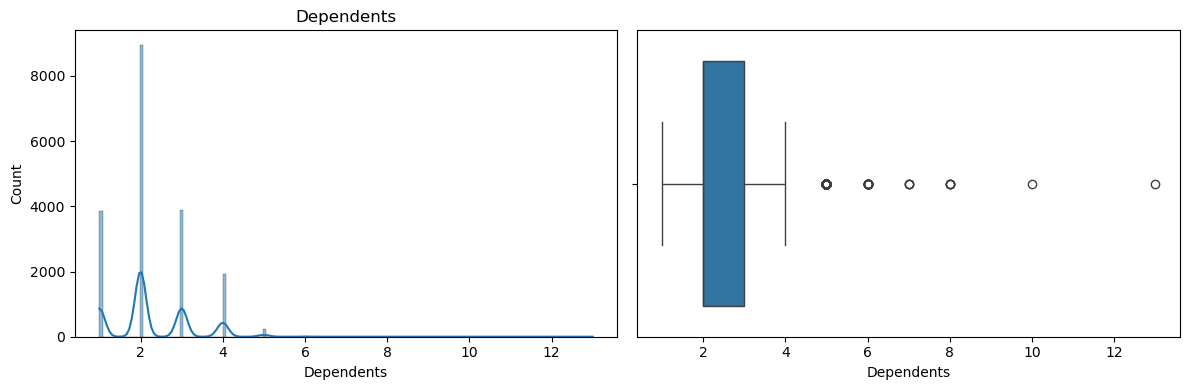

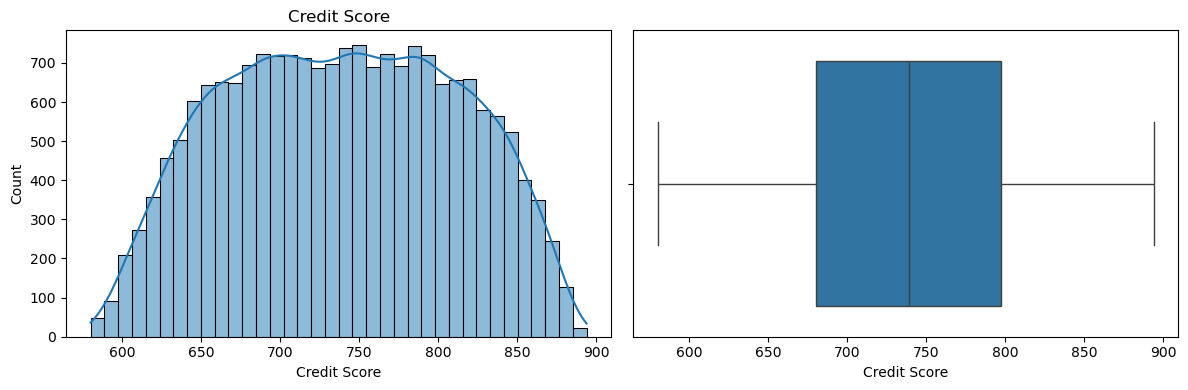

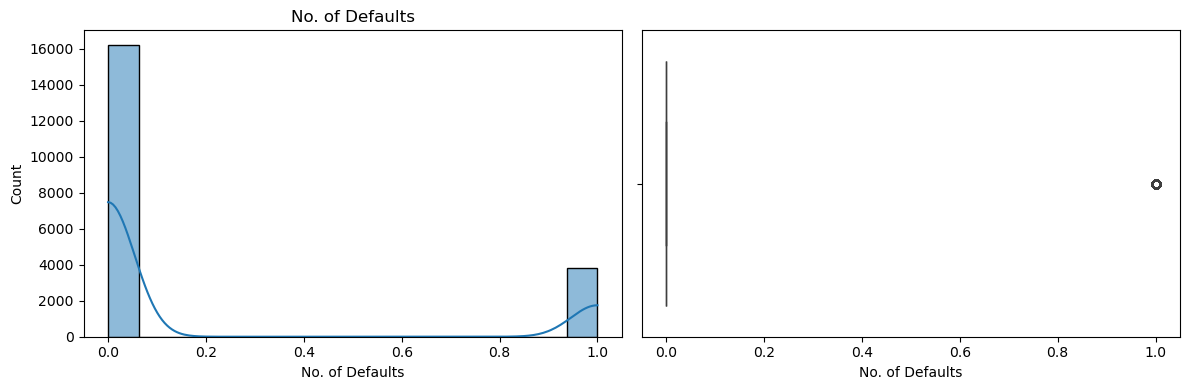

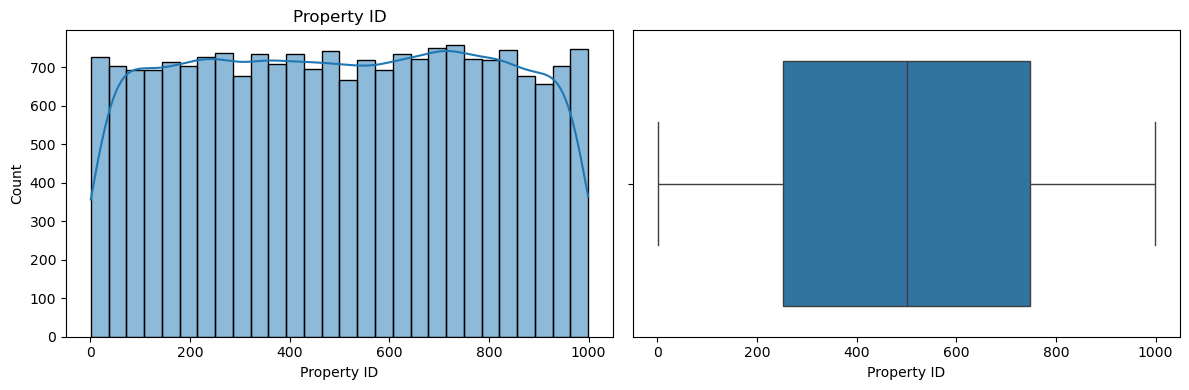

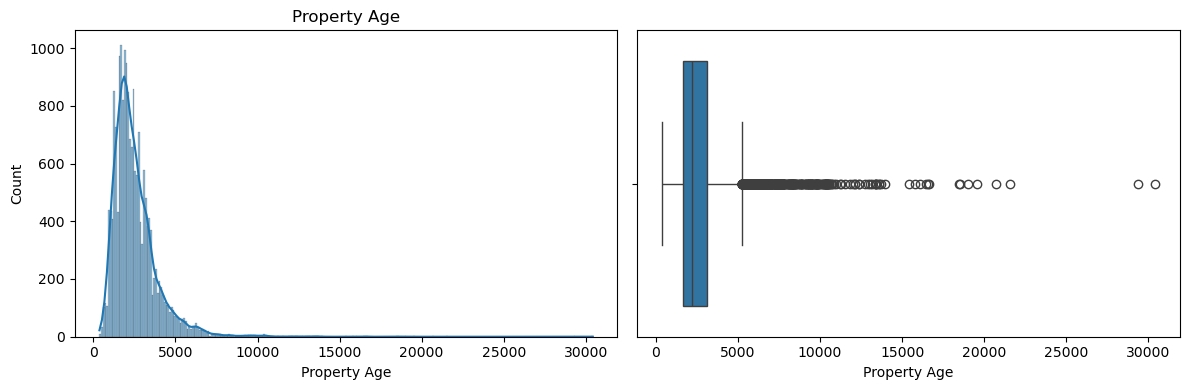

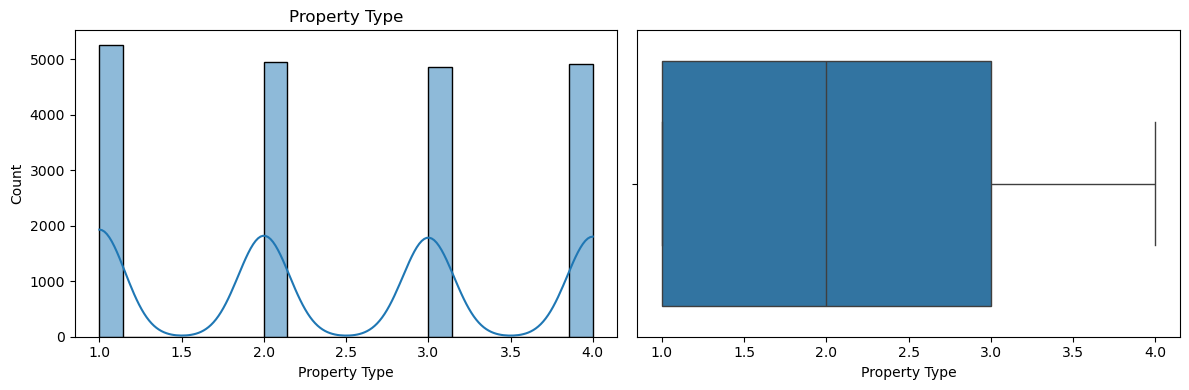

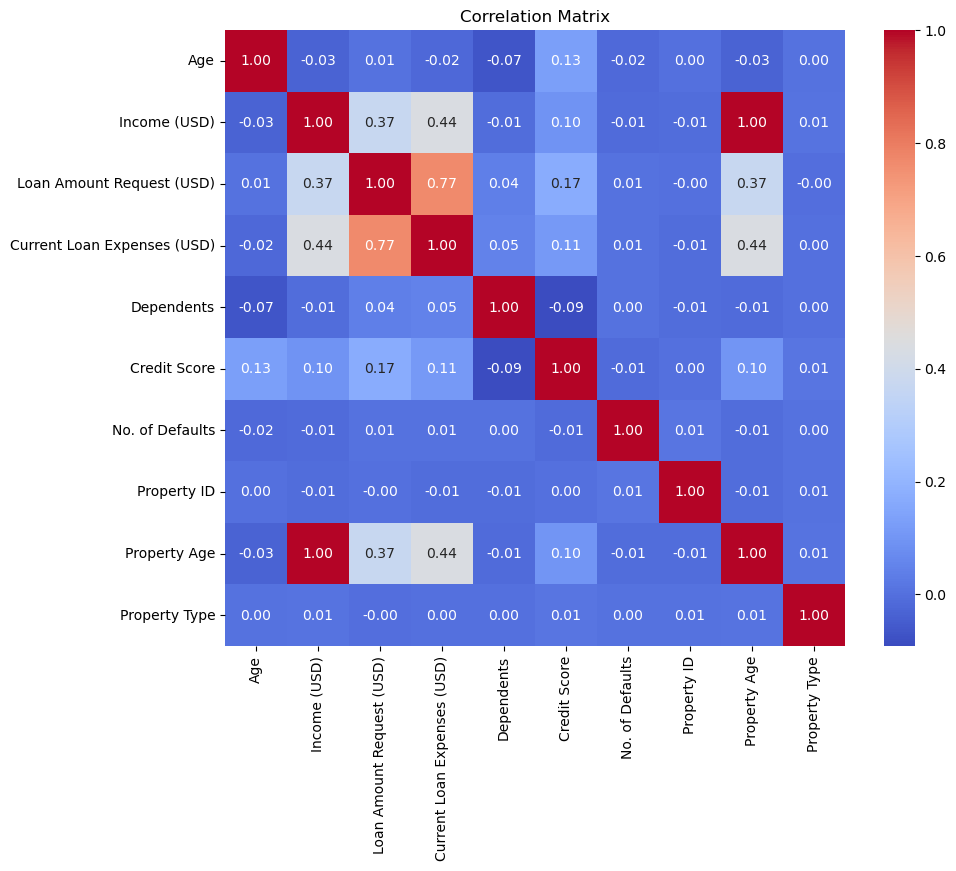

Pairplot skipped.

Outlier Count
Age : 0
Income (USD) : 831
Loan Amount Request (USD) : 511
Current Loan Expenses (USD) : 486
Dependents : 275
Credit Score : 0
No. of Defaults : 3790
Property ID : 0
Property Age : 822
Property Type : 0

Learning Type : SUPERVISED
Problem : Classification


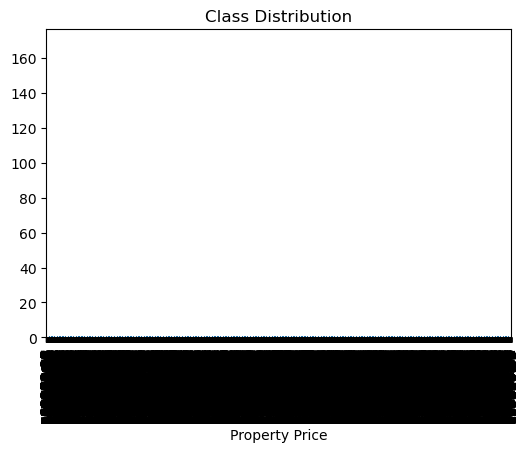


Skewness
Age : 0.055
Income (USD) : 3.41
Loan Amount Request (USD) : 1.278
Current Loan Expenses (USD) : 1.378
Dependents : 0.807
Credit Score : -0.012
No. of Defaults : 1.585
Property ID : -0.007
Property Age : 3.358
Property Type : 0.034

Kurtosis
Age : -1.387
Income (USD) : 31.052
Loan Amount Request (USD) : 1.971
Current Loan Expenses (USD) : 5.452
Dependents : 1.47
Credit Score : -0.991
No. of Defaults : 0.511
Property ID : -1.194
Property Age : 30.483
Property Type : -1.376


ValueError: Input X contains NaN.
SelectKBest does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [6]:
result = ml_lab_pipeline(
    "/home/mtech2/ML_Lab/test.csv",
   target_column="Property Price",
    k=10
)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
df = pd.read_csv("/home/mtech2/ML_Lab/test.csv")

target = "Loan Amount Request (USD)"

X = df.drop(columns=[target])
y = df[target]

In [ ]:
numeric_features = X.select_dtypes(include=["int64","float64"]).columns

categorical_features = X.select_dtypes(include=["object"]).columns

In [ ]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [ ]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [12]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

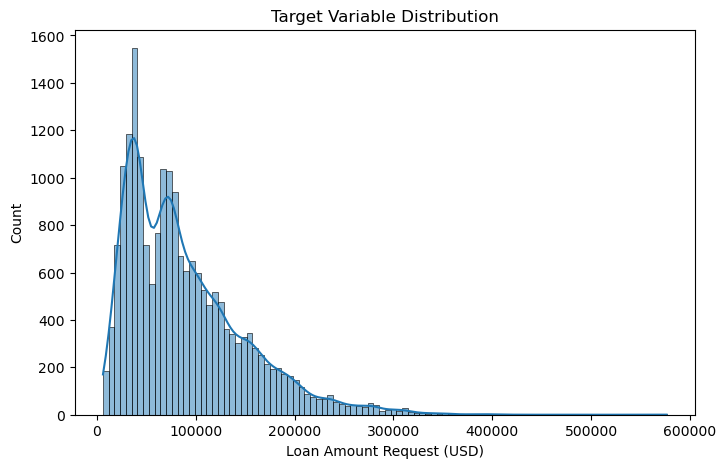

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(y,kde=True)
plt.title("Target Variable Distribution")
plt.show()

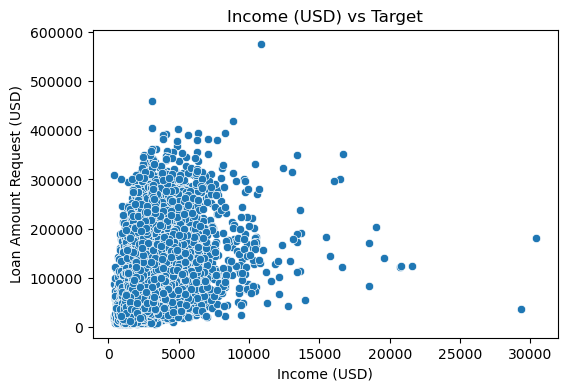

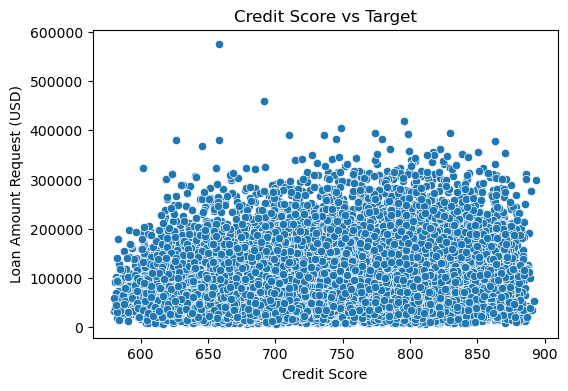

In [15]:
important = [
    "Income (USD)",
    "Credit Score",
]

for col in important:

    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col],y=df[target])

    plt.title(f"{col} vs Target")
    plt.show()

In [ ]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

start = time.time()

linear_model.fit(X_train,y_train)

linear_time = time.time()-start

linear_pred = linear_model.predict(X_test)

In [ ]:
ridge = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

ridge_param = {
    "model__alpha":[0.01,0.1,1,10,100]
}

ridge_grid = GridSearchCV(
    ridge,
    ridge_param,
    cv=5,
    scoring="r2"
)

start=time.time()

ridge_grid.fit(X_train,y_train)

ridge_time=time.time()-start

ridge_pred=ridge_grid.predict(X_test)

In [ ]:
lasso = Pipeline([
    ("preprocessor", preprocessor),
    ("model",Lasso(max_iter=5000))
])

lasso_param={
    "model__alpha":[0.001,0.01,0.1,1,10]
}

lasso_grid=GridSearchCV(
    lasso,
    lasso_param,
    cv=5,
    scoring="r2"
)

start=time.time()

lasso_grid.fit(X_train,y_train)

lasso_time=time.time()-start

lasso_pred=lasso_grid.predict(X_test)

In [ ]:
def evaluate(y_true,y_pred):

    mae=mean_absolute_error(y_true,y_pred)

    mse=mean_squared_error(y_true,y_pred)

    rmse=np.sqrt(mse)

    r2=r2_score(y_true,y_pred)

    return mae,mse,rmse,r2

In [ ]:
results=[]

models={
    "Linear Regression":(linear_pred,linear_time),
    "Ridge Regression":(ridge_pred,ridge_time),
    "Lasso Regression":(lasso_pred,lasso_time),
    "Elastic Net":(elastic_pred,elastic_time)
}

for name,(pred,t) in models.items():

    mae,mse,rmse,r2=evaluate(y_test,pred)

    results.append([
        name,
        mae,
        mse,
        rmse,
        r2,
        t
    ])

performance=pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R2",
        "Training Time"
    ]
)

print(performance)